# Income Tax Fraud Detection — Enterprise ML Pipeline

**What this notebook actually trains:** a classifier on the UCI **Census Income** dataset that
predicts whether a person's income is above or below $50K, using demographic and employment
census fields (age, workclass, education, marital status, occupation, race, sex, capital
gain/loss, hours worked, native country).

**What it does *not* do:** measure fraud. There is no filing history, audit outcome, or
reported-vs-verified discrepancy anywhere in this data — "high income" is not evidence of
fraud. Treating it as a fraud proxy means the model's real function is predicting income from
demographic attributes (including race, sex, marital status, and national origin) and handing
that prediction to a downstream fraud/audit process. If this is ever wired to a real decision
about who gets investigated or audited, that would mean using protected attributes to drive an
investigative outcome with no actual fraud signal behind it. Treat this notebook as an
income-classification exercise, not an audit-worthy fraud model, unless it is retrained on data
with real fraud/audit outcomes as the label.

**Changes from the previous version of this notebook**, based on a review that found the saved
notebook errored out partway through and never finished running:
- Hyperparameter search now runs in parallel (`n_jobs=-1`) instead of one fit at a time — the
  previous version hung on a sequential 60-fit Gradient Boosting search and was interrupted
  before finishing.
- Fixing that also surfaced a second bug the interrupted run never reached: `scoring="f1"`
  silently assumes `pos_label=1`, which doesn't exist for the `"<=50K"`/`">50K"` string labels
  used here. Every candidate was scoring `NaN`. Replaced with an explicit scorer.
- Model selection and decision-threshold tuning now use a dedicated **validation** split
  instead of the test set, so the test set is touched exactly once, at the end, to report final
  numbers — previously it was reused across five separate steps.
- Class imbalance (76% / 24%) is now handled consistently: Random Forest and Decision Tree get
  `class_weight="balanced"` (they support it natively and weren't using it), Gradient Boosting
  and Naive Bayes get weighted via `sample_weight`. MLP and KNN have no native reweighting
  mechanism in scikit-learn, which is now noted explicitly rather than left as a silent gap.
- `predict_proba(...)[:, 1]` (four places) is replaced with an explicit lookup of the positive
  class's column, rather than relying on alphabetical label ordering.
- The global `warnings.filterwarnings("ignore", category=UserWarning)` is removed —
  it was also hiding `ConvergenceWarning` from the neural network.
- Saved metadata now includes the scikit-learn/pandas/numpy/Python versions the model was
  trained with, since a pickled pipeline loaded by a separate service is exactly where a
  version mismatch silently breaks.
- The duplicate bake-off table (old sections 7 and 11) is consolidated into one.

**Design principles:** reproducible splits, leakage-safe `sklearn` pipelines, imbalance-aware
metrics, hyperparameter search inside CV, a train / validation / test split so the test set is
touched exactly once, and serialized artifacts for the Django API in `fraud_app/`.

## 1. Configuration

In [2]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

# No blanket warning suppression here on purpose — ConvergenceWarning (a UserWarning
# subclass) is exactly the signal that would tell us if the MLP didn't converge, and a
# global filter was hiding it in the previous version.

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001


def resolve_project_root() -> Path:
    """Find the folder that contains census-income.csv (works in Jupyter and CLI)."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "census-income.csv").exists():
            return candidate
    return Path.cwd()


# --- Reproducibility & paths ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NOTEBOOK_DIR = resolve_project_root()
DATA_PATH = NOTEBOOK_DIR / "census-income.csv"
ARTIFACT_DIR = NOTEBOOK_DIR / "artifacts"
# fraud_app/ is the existing Django app's expected model location — kept as-is so this
# still drops into that integration; see the caveat above about what the model can
# responsibly be used for.
MODEL_PATH = NOTEBOOK_DIR / "fraud_app" / "model.pkl"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_PATH.parent.mkdir(exist_ok=True)

POSITIVE_LABEL = ">50K"
NEGATIVE_LABEL = "<=50K"
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.25  # 25% of the remaining 80% of rows -> 20% of the full dataset
CV_FOLDS = 5
N_JOBS = -1  # was 1 — a sequential 60-fit search on Gradient Boosting is what hung before

FEATURE_COLUMNS = [
    "age",
    "workclass",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
]
TARGET_COLUMN = "income"

CATEGORICAL_FEATURES = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]
NUMERIC_FEATURES = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

# The "f1" scoring shorthand resolves to f1_score(pos_label=1), which raises on string
# labels ("pos_label=1 is not a valid label"). Bind pos_label explicitly instead.
F1_SCORER = make_scorer(f1_score, pos_label=POSITIVE_LABEL, zero_division=0)


def positive_class_index(fitted_estimator, positive_label: str = POSITIVE_LABEL) -> int:
    """Index of `positive_label` in a fitted estimator's classes_.

    predict_proba(...)[:, 1] happened to be correct four times over in the previous
    version because sklearn sorts string classes alphabetically and "<" sorts before
    ">" — but that's implicit and silently breaks if the labels ever change. This looks
    the index up explicitly instead.
    """
    return list(fitted_estimator.classes_).index(positive_label)


logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("fraud-training")

## 2. Load & validate data

In [3]:
def clean_census_frame(raw: pd.DataFrame) -> pd.DataFrame:
    """Normalize whitespace and standardize missing tokens."""
    df = raw.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"?": np.nan, "": np.nan})
    return df


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

raw_df = pd.read_csv(DATA_PATH)
df = clean_census_frame(raw_df)

missing = df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum()
logger.info("Loaded %s rows from %s", f"{len(df):,}", DATA_PATH.name)
display(df[FEATURE_COLUMNS + [TARGET_COLUMN]].head())
print("\nMissing values (after cleaning):")
print(missing[missing > 0].sort_values(ascending=False))
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).round(4))

INFO | Loaded 48,842 rows from census-income.csv


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Missing values (after cleaning):
occupation        2809
workclass         2799
native-country     857
dtype: int64

Target distribution:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


## 3. Exploratory analysis

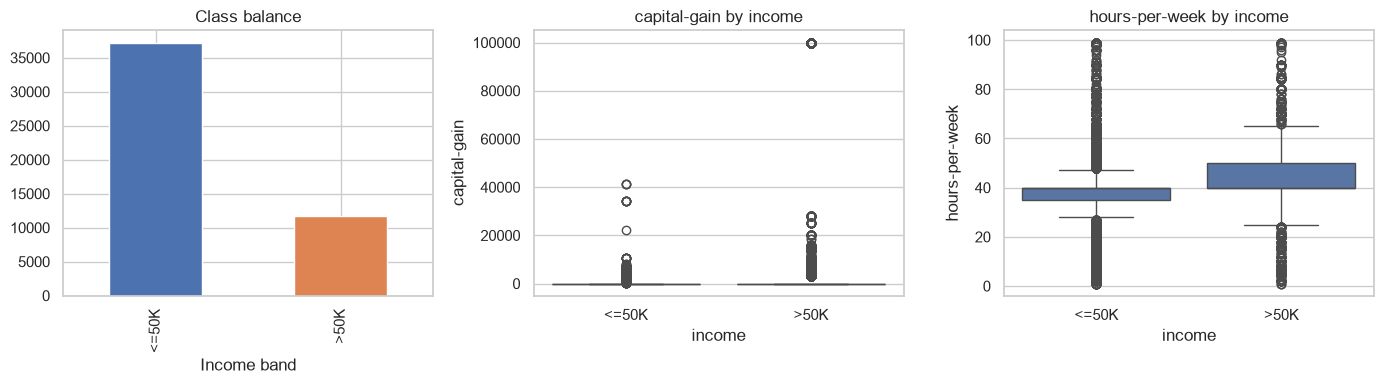

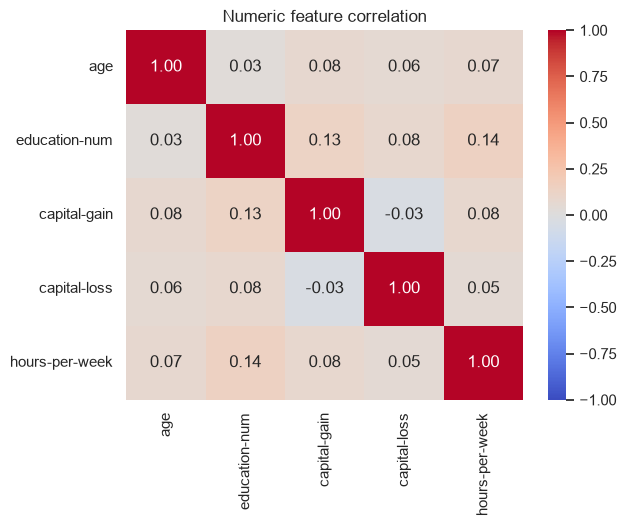

In [4]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Income band")

for ax, col in zip(axes[1:], ["capital-gain", "hours-per-week"]):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, ax=ax)
    ax.set_title(f"{col} by income")

plt.tight_layout()
plt.show()

corr_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric feature correlation")
plt.show()

## 4. Prepare features & three-way split (train / validation / test)

Previously this was a single 80/20 train/test split, and the test set ended up doing double
duty: picking the winning model family *and* reporting final performance. Splitting out a
dedicated validation set means every selection decision (model family, threshold) happens on
data the final model never gets evaluated against, and the test set only gets touched once, at
the very end.

In [5]:
model_df = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

logger.info(
    "Train: %s | Validation: %s | Test: %s",
    f"{len(X_train):,}", f"{len(X_val):,}", f"{len(X_test):,}",
)

INFO | Train: 29,304 | Validation: 9,769 | Test: 9,769


## 5. Leakage-safe preprocessing pipeline

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)


def build_pipeline(estimator) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", estimator),
        ]
    )

## 6. Train candidate models (training set only)

Imbalance handling is now consistent and explicit: `RandomForestClassifier` and
`DecisionTreeClassifier` both support `class_weight="balanced"` natively and previously weren't
using it, so only 2 of 7 models were getting any rebalancing. `GaussianNB` supports
`sample_weight` in `.fit()`, so it's added there too, the same way `GradientBoostingClassifier`
already handled it. `MLPClassifier` and `KNeighborsClassifier` genuinely have no
class-weighting or sample-weighting mechanism in scikit-learn — that's called out below rather
than left as a silent inconsistency.

In [7]:
MODEL_SPECS = [
    ("Logistic Regression", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="saga", class_weight="balanced")),
    ("Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    ("Random Forest", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, class_weight="balanced")),
    ("Feed Forward Neural Network", MLPClassifier(random_state=RANDOM_STATE, max_iter=1000)),
    ("k-Nearest Neighbors", KNeighborsClassifier()),
    ("Naive Bayes", GaussianNB()),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=RANDOM_STATE)),
]

# Models with no native class_weight support that get rebalanced via sample_weight instead.
SAMPLE_WEIGHTED_MODELS = {"Gradient Boosting", "Naive Bayes"}
# Models with no rebalancing lever available in scikit-learn at all — left as-is, noted here
# instead of silently omitted.
UNWEIGHTED_MODELS = {"Feed Forward Neural Network", "k-Nearest Neighbors"}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
models = []

for name, estimator in MODEL_SPECS:
    pipe = build_pipeline(estimator)
    if name in SAMPLE_WEIGHTED_MODELS:
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        pipe.fit(X_train, y_train, classifier__sample_weight=sample_weight)
    else:
        pipe.fit(X_train, y_train)
    models.append((name, pipe))
    print(f"{name} training complete.")

print("All models trained successfully.")

Logistic Regression training complete.
Decision Tree training complete.
Random Forest training complete.
Feed Forward Neural Network training complete.
k-Nearest Neighbors training complete.
Naive Bayes training complete.
Gradient Boosting training complete.
All models trained successfully.


## 7. Model comparison on the validation set

Evaluated on the validation set, not the test set, since this comparison drives which model
family gets tuned next. F1 is the metric that actually drives the decision below (`idxmax` on
the F1 column) — on a 76/24 imbalanced target, accuracy alone is a weak signal, since always
predicting the majority class already scores about 76%, so it's shown for reference but isn't
what picks the winner. This also consolidates what used to be two duplicate tables (old
sections 7 and 11).

Model performance on the validation set:


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.8073,0.5647,0.8494,0.6784
Decision Tree,0.8168,0.6046,0.6765,0.6385
Random Forest,0.8322,0.6262,0.7411,0.6788
Feed Forward Neural Network,0.8459,0.6867,0.6547,0.6703
k-Nearest Neighbors,0.8368,0.6803,0.5999,0.6376
Naive Bayes,0.5435,0.3390,0.9568,0.5007
Gradient Boosting,0.8254,0.5927,0.8631,0.7028


INFO | Best model by validation F1-score: Gradient Boosting


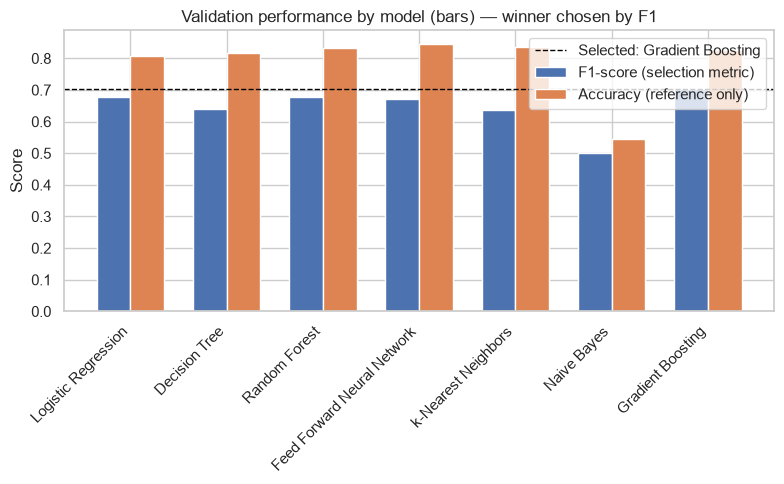

In [8]:
results = {}
for name, model in models:
    y_pred = model.predict(X_val)
    results[name] = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "Recall": recall_score(y_val, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "F1-score": f1_score(y_val, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
    }

results_df = pd.DataFrame(results).T.round(4)
print("Model performance on the validation set:")
display(results_df)

best_model_name = results_df["F1-score"].idxmax()
logger.info("Best model by validation F1-score: %s", best_model_name)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width / 2, results_df["F1-score"], width, label="F1-score (selection metric)", color="#4C72B0")
ax.bar(x + width / 2, results_df["Accuracy"], width, label="Accuracy (reference only)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Validation performance by model (bars) — winner chosen by F1")
ax.axhline(results_df.loc[best_model_name, "F1-score"], color="black", linestyle="--", linewidth=1,
           label=f"Selected: {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Overfitting / underfitting check

Compare training and validation performance for each candidate model to detect
whether the model is overfitting (large train/validation gap) or underfitting
(low scores on both).


Training vs validation performance:


,Train Accuracy,Val Accuracy,Train F1,Val F1,F1 Gap
Model,,,,,
Logistic Regression,0.8070,0.8073,0.6785,0.6784,0.0001
Decision Tree,0.9703,0.8168,0.9413,0.6385,0.3028
Random Forest,0.9652,0.8322,0.9318,0.6788,0.2530
Feed Forward Neural Network,0.8910,0.8459,0.7684,0.6703,0.0981
k-Nearest Neighbors,0.8807,0.8368,0.7366,0.6376,0.0991
Naive Bayes,0.5415,0.5435,0.4998,0.5007,-0.0009
Gradient Boosting,0.8241,0.8254,0.7041,0.7028,0.0013


<Figure size 1000x500 with 0 Axes>

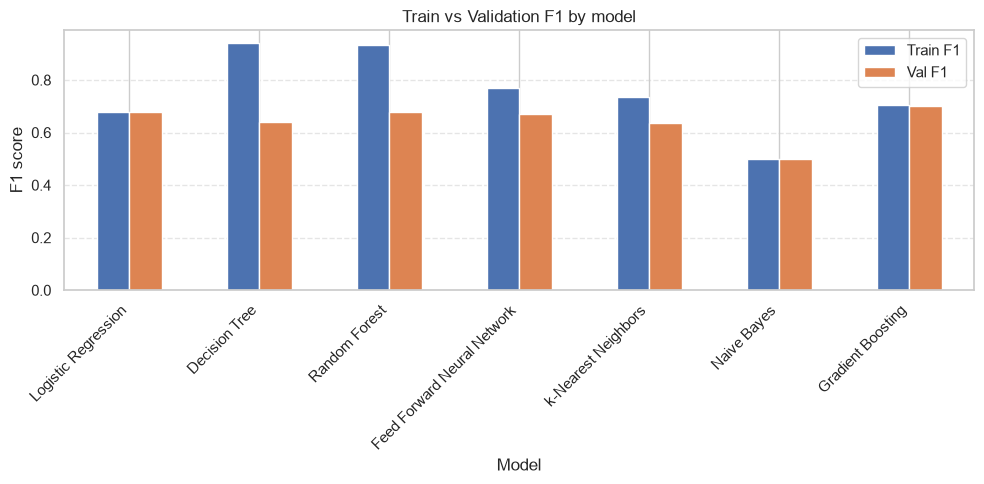

Larger F1 gaps indicate potential overfitting. Low scores on both datasets indicate potential underfitting.


In [9]:
train_val_records = []
for name, model in models:
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    train_val_records.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "Val F1": f1_score(y_val, val_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "F1 Gap": float(f1_score(y_train, train_pred, pos_label=POSITIVE_LABEL, zero_division=0) - f1_score(y_val, val_pred, pos_label=POSITIVE_LABEL, zero_division=0)),
    })

train_val_df = pd.DataFrame(train_val_records).set_index("Model")
print("Training vs validation performance:")
display(train_val_df.round(4))

plt.figure(figsize=(10, 5))
train_val_df[["Train F1", "Val F1"]].plot(kind="bar", figsize=(10, 5))
plt.title("Train vs Validation F1 by model")
plt.ylabel("F1 score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Larger F1 gaps indicate potential overfitting. Low scores on both datasets indicate potential underfitting.")

## 9. ROC curve (validation set)

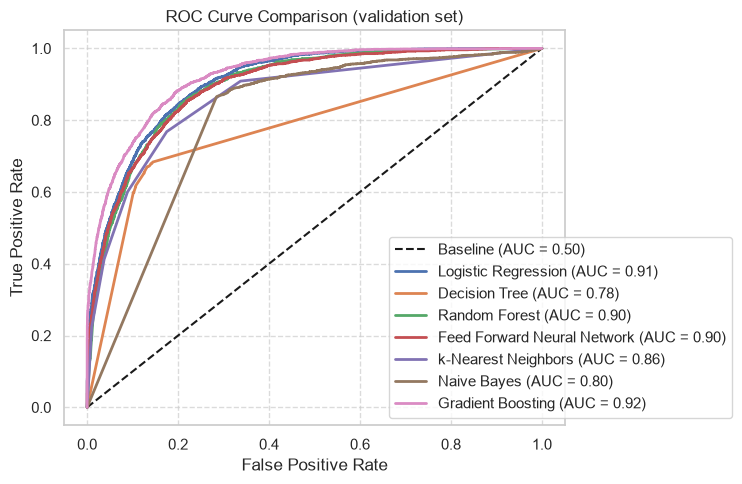

In [10]:
plt.figure(figsize=(8, 5))
plt.plot([0, 1], [0, 1], "k--", label="Baseline (AUC = 0.50)")

for name, model in models:
    if not hasattr(model, "predict_proba"):
        print(f"Model {name} doesn't support predict_proba - skipping")
        continue

    pos_idx = positive_class_index(model)
    y_probs = model.predict_proba(X_val)[:, pos_idx]
    fpr, tpr, _ = roc_curve(y_val, y_probs, pos_label=POSITIVE_LABEL)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})", linewidth=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (validation set)")
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 10. Precision-Recall curve (validation set)

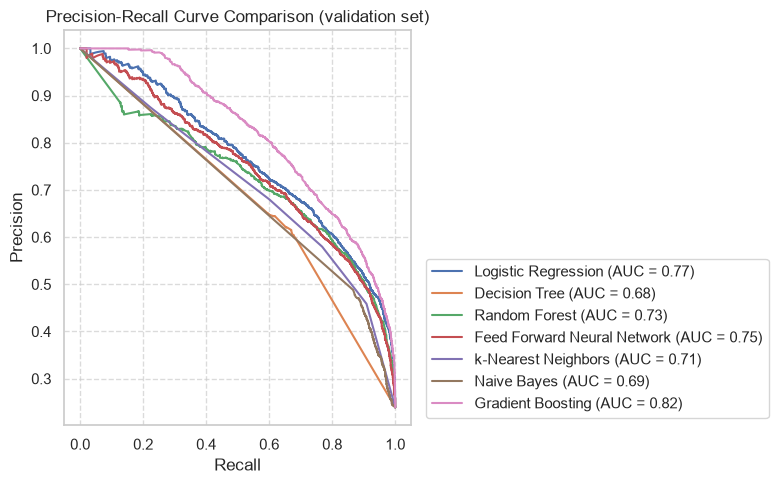

In [11]:
plt.figure(figsize=(8, 5))

for name, model in models:
    if hasattr(model, "predict_proba"):
        pos_idx = positive_class_index(model)
        y_scores = model.predict_proba(X_val)[:, pos_idx]
    elif hasattr(model, "decision_function"):
        # decision_function's sign convention also depends on classes_ ordering (positive
        # scores favor classes_[1]) - same caveat as predict_proba, just no column to index.
        y_scores = model.decision_function(X_val)
    else:
        print(f"Model {name} doesn't support probability estimates")
        continue

    precision, recall, _ = precision_recall_curve(y_val, y_scores, pos_label=POSITIVE_LABEL)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison (validation set)")
plt.legend(loc="lower left", bbox_to_anchor=(1.02, 0))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 11. Hyperparameter tuning (best model by validation F1, tuned via CV on the training set)

This is the step that hung before: with `n_jobs=1`, 12 candidates × 5 folds meant 60 fully
sequential Gradient Boosting fits with no early stopping. `n_jobs=-1` parallelizes across
folds/candidates, and `n_iter_no_change`/`validation_fraction` let bad candidates bail out
early. Scoring uses the explicit `F1_SCORER` from Section 1 instead of the `"f1"` string, which
would otherwise silently score every candidate as `NaN` on these string labels.

In [ ]:
candidate_models = dict(MODEL_SPECS)
base_estimator = candidate_models[best_model_name]
search_pipe = build_pipeline(base_estimator)

param_spaces = {
    "Logistic Regression": {
        "classifier__C": np.logspace(-2, 2, 12),
        "classifier__penalty": ["l2"],
    },
    "Decision Tree": {
        "classifier__max_depth": [None, 8, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "Random Forest": {
        "classifier__n_estimators": [150, 200, 300],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2"],
    },
    "Feed Forward Neural Network": {
        "classifier__hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "classifier__alpha": [0.0001, 0.001, 0.01],
    },
    "k-Nearest Neighbors": {
        "classifier__n_neighbors": [3, 5, 7, 11],
        "classifier__weights": ["uniform", "distance"],
    },
    "Naive Bayes": {
        "classifier__var_smoothing": np.logspace(-10, -7, 4),
    },
    "Gradient Boosting": {
        "classifier__n_estimators": [100, 150, 200],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [2, 3],
        "classifier__subsample": [0.8, 1.0],
        "classifier__n_iter_no_change": [10],       # early stopping -> bad candidates bail early
        "classifier__validation_fraction": [0.1],
    },
}

fit_params = {}
if best_model_name in SAMPLE_WEIGHTED_MODELS:
    fit_params = {
        "classifier__sample_weight": compute_sample_weight(class_weight="balanced", y=y_train)
    }

search = RandomizedSearchCV(
    estimator=search_pipe,
    param_distributions=param_spaces[best_model_name],
    n_iter=12,
    scoring=F1_SCORER,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train, **fit_params)
tuned_model = search.best_estimator_

print("Best params:", search.best_params_)
print(f"Best CV F1: {search.best_score_:.4f}")

## 12. Decision threshold tuning (validation set)

Uses the tuned model's predictions on the validation set — not the test set — so the threshold
is chosen without ever looking at the data the final numbers will be reported on.

In [ ]:
pos_idx = positive_class_index(tuned_model)
y_val_proba = tuned_model.predict_proba(X_val)[:, pos_idx]

precision, recall, thresholds = precision_recall_curve(
    y_val, y_val_proba, pos_label=POSITIVE_LABEL
)
f1_scores = (2 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
best_idx = int(np.argmax(f1_scores))
optimal_threshold = float(thresholds[best_idx])

plt.figure(figsize=(7, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(optimal_threshold, color="black", linestyle="--", label=f"Optimal ≈ {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / recall vs threshold (validation set)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold (chosen on validation): {optimal_threshold:.4f}")

## 13. Refit on train + validation, then a single hold-out evaluation on the test set

Model family, hyperparameters, and decision threshold are all locked in now, using only
`X_train`/`X_val`. There's no more reason to hold validation data back from training, so the
final pipeline is refit on `X_train` + `X_val` combined with the winning hyperparameters, and
`X_test` is evaluated exactly once here — the only place it's used after the Section 4 split.

In [ ]:
final_model = build_pipeline(candidate_models[best_model_name]).set_params(**search.best_params_)

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

refit_kwargs = {}
if best_model_name in SAMPLE_WEIGHTED_MODELS:
    refit_kwargs = {
        "classifier__sample_weight": compute_sample_weight(class_weight="balanced", y=y_trainval)
    }
final_model.fit(X_trainval, y_trainval, **refit_kwargs)

pos_idx = positive_class_index(final_model)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, pos_idx]

print(classification_report(y_test, y_pred, target_names=[NEGATIVE_LABEL, POSITIVE_LABEL]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=[NEGATIVE_LABEL, POSITIVE_LABEL], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion matrix (test set)")

RocCurveDisplay.from_predictions(y_test, y_proba, pos_label=POSITIVE_LABEL, ax=axes[1])
axes[1].set_title("ROC curve (test set)")
plt.tight_layout()
plt.show()

holdout_metrics = {
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "avg_precision": float(average_precision_score(y_test, y_proba, pos_label=POSITIVE_LABEL)),
    "f1": float(f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL, zero_division=0)),
}
print("Hold-out metrics (test set, touched once):", json.dumps(holdout_metrics, indent=2))

y_tuned = np.where(y_proba >= optimal_threshold, POSITIVE_LABEL, NEGATIVE_LABEL)
print("\nTuned-threshold confusion matrix (test set):")
print(confusion_matrix(y_test, y_tuned, labels=[NEGATIVE_LABEL, POSITIVE_LABEL]))
print(f"Tuned F1 @ threshold (test set): {f1_score(y_test, y_tuned, pos_label=POSITIVE_LABEL, zero_division=0):.4f}")

## 14. Persist production artifacts

Metadata now also records the library/interpreter versions the model was trained with — a
pickled scikit-learn pipeline loaded by a different environment (the Django app) is exactly
where a version mismatch can silently break or mis-predict.

In [ ]:
metadata = {
    "model_family": best_model_name,
    "best_params": search.best_params_,
    "feature_columns": FEATURE_COLUMNS,
    "positive_label": POSITIVE_LABEL,
    "decision_threshold": optimal_threshold,
    "holdout_metrics": holdout_metrics,
    "random_state": RANDOM_STATE,
    "n_train_val_rows": int(len(X_trainval)),
    "n_test_rows": int(len(X_test)),
    "environment": {
        "python": sys.version.split()[0],
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

joblib.dump(final_model, MODEL_PATH)
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

logger.info("Saved pipeline -> %s", MODEL_PATH)
logger.info("Saved metadata -> %s", METADATA_PATH)

## 15. Inference smoke test (Django-compatible payload)

In [ ]:
loaded_model = joblib.load(MODEL_PATH)

sample_payload = pd.DataFrame(
    [
        {
            "age": 35,
            "workclass": "Private",
            "education-num": 10,
            "marital-status": "Never-married",
            "occupation": "Other-service",
            "relationship": "Not-in-family",
            "race": "White",
            "sex": "Male",
            "capital-gain": 1000,
            "capital-loss": 0,
            "hours-per-week": 40,
            "native-country": "United-States",
        }
    ]
)

pos_idx = positive_class_index(loaded_model)
sample_proba = float(loaded_model.predict_proba(sample_payload)[0, pos_idx])
sample_label = POSITIVE_LABEL if sample_proba >= optimal_threshold else NEGATIVE_LABEL

print(f"Sample probability ({POSITIVE_LABEL}): {sample_proba:.3f}")
print(f"Sample decision @ threshold {optimal_threshold:.2f}: {sample_label}")